# EDA Big Data: NYC Airbnb 2019

Notebook ini disusun sesuai catatan dosen:

1. EDA Big Data = seni dan sains memahami data skala besar sebelum model dibangun.
2. Tujuan EDA = mengurangi ketidakpastian dari data mentah menjadi fakta yang dapat ditindaklanjuti.
3. Skalabilitas = hindari operasi mahal tanpa filter; gunakan projection, predicate pushdown, dan agregasi bertahap.
4. Visual bukan hiasan: setiap grafik wajib menjawab pertanyaan.
5. Cek bias sampling: bandingkan distribusi sampel vs agregat global.
6. Tulis batasan analisis dan rekomendasi realistis.

**Pertanyaan pendukung untuk catatan nomor 4 (dipakai sebelum setiap grafik):**

> Grafik ini dibuat untuk menjawab keputusan apa, dan tindakan apa yang berubah jika polanya berbeda?

In [73]:
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

# Download latest version
dataset_handle = "dgomonov/new-york-city-airbnb-open-data"
path = kagglehub.dataset_download(dataset_handle)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [74]:
# Prinsip skalabilitas 1: projection (ambil kolom yang relevan saja)
selected_cols = [
    "id",
    "host_id",
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "last_review",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

# last_review diparse saat load untuk efisiensi langkah berikutnya
df_raw = pd.read_csv(
    f"{path}/AB_NYC_2019.csv",
    usecols=selected_cols,
    parse_dates=["last_review"],
)

# Prinsip skalabilitas 2: predicate pushdown style (filter awal agar langkah lanjut lebih ringan)
mask_valid = (
    (df_raw["price"] > 0)
    & (df_raw["availability_365"].between(0, 365))
    & (df_raw["latitude"].between(40.45, 40.95))
    & (df_raw["longitude"].between(-74.30, -73.65))
)

df = df_raw.loc[mask_valid].copy()

print(f"Baris awal (global): {len(df_raw):,}")
print(f"Baris setelah filter validitas dasar: {len(df):,}")
print(f"Baris terbuang: {len(df_raw) - len(df):,}")

df.head(5)

Baris awal (global): 48,895
Baris setelah filter validitas dasar: 48,884
Baris terbuang: 11


,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [75]:
def fmt_num(x, digits=2):
    if pd.isna(x):
        return "NA"
    if abs(x) >= 1000:
        return f"{x:,.{digits}f}"
    return f"{x:.{digits}f}"


def ask_plot(question):
    display(Markdown(f"**Pertanyaan grafik:** {question}"))


def explain_plot(points):
    bullet_text = "\n".join([f"- {p}" for p in points])
    display(Markdown(f"**Interpretasi (bahasa sederhana):**\n{bullet_text}"))


def section(title):
    display(Markdown(f"## {title}"))

## 1) Data Inventory dan Reduksi Ketidakpastian

,indikator,nilai
0,jumlah_baris,48884
1,jumlah_kolom,14
2,duplikasi_baris,0


### Tabel Missing Value

,missing_count,missing_pct
last_review,10051,20.56092
reviews_per_month,10051,20.56092
neighbourhood_group,0,0.00000
neighbourhood,0,0.00000
id,0,0.00000
host_id,0,0.00000
longitude,0,0.00000
latitude,0,0.00000
room_type,0,0.00000
price,0,0.00000


### Tabel Kardinalitas

,kolom_kategorikal,jumlah_kategori_unik
0,neighbourhood_group,5
1,neighbourhood,221
2,room_type,3


**Pertanyaan grafik:** Kolom mana yang paling banyak missing, dan apakah missing tersebut bersifat informatif?

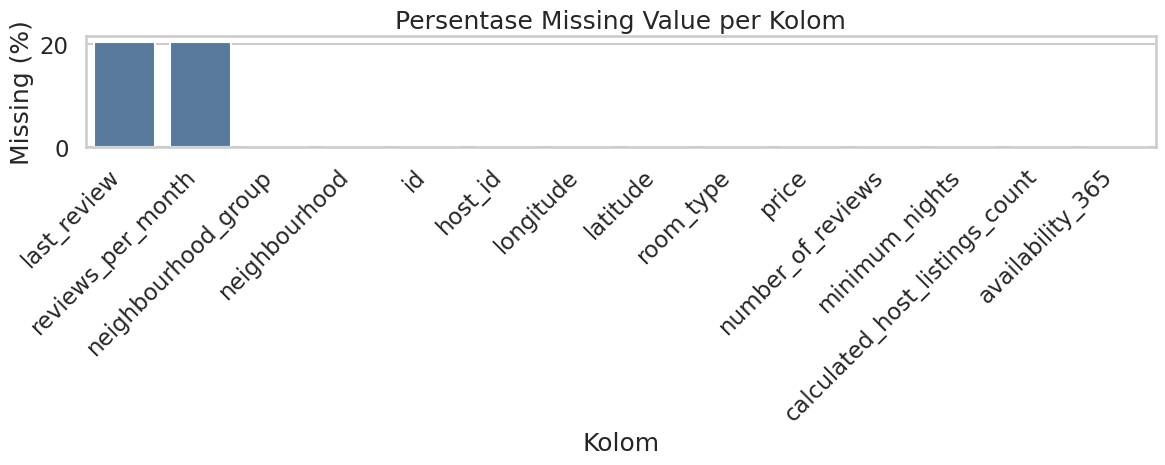

**Interpretasi (bahasa sederhana):**
- Kolom yang paling sering kosong adalah last_review (20.56%) dan reviews_per_month (20.56%).
- Data kosong pada dua kolom ini hampir selalu muncul bersamaan (100.00%). Ini biasanya berarti listing belum punya review.
- Jadi, nilai kosong di sini lebih mungkin karena kondisi bisnis, bukan karena data rusak acak.

In [76]:
section("1) Data Inventory dan Reduksi Ketidakpastian")

shape_df = pd.DataFrame(
    {
        "indikator": ["jumlah_baris", "jumlah_kolom", "duplikasi_baris"],
        "nilai": [len(df), df.shape[1], int(df.duplicated().sum())],
    }
)

display(shape_df)

missing_tbl = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_pct", ascending=False)
)

cardinality_tbl = pd.DataFrame(
    {
        "kolom_kategorikal": ["neighbourhood_group", "neighbourhood", "room_type"],
        "jumlah_kategori_unik": [
            df["neighbourhood_group"].nunique(),
            df["neighbourhood"].nunique(),
            df["room_type"].nunique(),
        ],
    }
)

display(Markdown("### Tabel Missing Value"))
display(missing_tbl)

display(Markdown("### Tabel Kardinalitas"))
display(cardinality_tbl)

ask_plot("Kolom mana yang paling banyak missing, dan apakah missing tersebut bersifat informatif?")
missing_plot = missing_tbl.reset_index().rename(columns={"index": "kolom"})
plt.figure(figsize=(12, 5))
sns.barplot(data=missing_plot, x="kolom", y="missing_pct", color="#4C78A8")
plt.title("Persentase Missing Value per Kolom")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing (%)")
plt.xlabel("Kolom")
plt.tight_layout()
plt.show()

missing_last_review = missing_tbl.loc["last_review", "missing_pct"] if "last_review" in missing_tbl.index else np.nan
missing_rpm = missing_tbl.loc["reviews_per_month", "missing_pct"] if "reviews_per_month" in missing_tbl.index else np.nan
null_sync = (df["last_review"].isna() == df["reviews_per_month"].isna()).mean() * 100

explain_plot(
    [
        f"Kolom yang paling sering kosong adalah last_review ({fmt_num(missing_last_review)}%) dan reviews_per_month ({fmt_num(missing_rpm)}%).",
        f"Data kosong pada dua kolom ini hampir selalu muncul bersamaan ({fmt_num(null_sync)}%). Ini biasanya berarti listing belum punya review.",
        "Jadi, nilai kosong di sini lebih mungkin karena kondisi bisnis, bukan karena data rusak acak.",
    ]
)

## 2) Cek Bias Sampling: Sampel vs Agregat Global

**Pertanyaan grafik:** Apakah distribusi borough pada sampel konsisten dengan agregat global?

,global_pct,sample_pct,abs_gap_pct
neighbourhood_group,,,
Manhattan,44.31,44.14,0.16
Brooklyn,41.11,41.28,0.17
Queens,11.59,11.46,0.14
Bronx,2.23,2.29,0.06
Staten Island,0.76,0.83,0.07


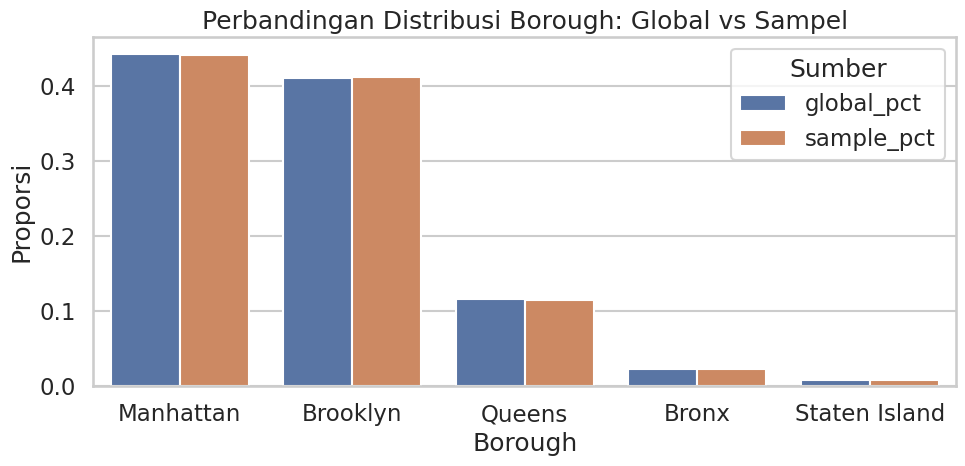

**Interpretasi (bahasa sederhana):**
- Selisih terbesar proporsi borough antara data sampel dan data penuh adalah 0.17 poin persentase.
- Kalau selisihnya kecil, sampel bisa dipakai untuk analisis cepat karena cukup mewakili data penuh.
- Cek ini penting supaya kita tidak mengambil kesimpulan dari sampel yang ternyata bias.

In [77]:
section("2) Cek Bias Sampling: Sampel vs Agregat Global")

# Ambil sampel terkontrol untuk simulasi kerja skala besar
sample_frac = 0.20
sample_df = df.sample(frac=sample_frac, random_state=42)

ask_plot("Apakah distribusi borough pada sampel konsisten dengan agregat global?")

global_borough = df["neighbourhood_group"].value_counts(normalize=True).rename("global_pct")
sample_borough = sample_df["neighbourhood_group"].value_counts(normalize=True).rename("sample_pct")
borough_compare = (
    pd.concat([global_borough, sample_borough], axis=1)
    .fillna(0)
    .assign(abs_gap_pct=lambda x: (x["global_pct"] - x["sample_pct"]).abs() * 100)
    .sort_values("global_pct", ascending=False)
)

borough_display = borough_compare.copy()
borough_display[["global_pct", "sample_pct"]] = borough_display[["global_pct", "sample_pct"]] * 100
display(borough_display.round(2))

borough_plot = borough_compare.reset_index()
first_col = borough_plot.columns[0]
borough_plot = borough_plot.rename(columns={first_col: "borough"})
borough_plot = borough_plot.melt(
    id_vars="borough",
    value_vars=["global_pct", "sample_pct"],
    var_name="sumber",
    value_name="proporsi",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=borough_plot, x="borough", y="proporsi", hue="sumber")
plt.title("Perbandingan Distribusi Borough: Global vs Sampel")
plt.ylabel("Proporsi")
plt.xlabel("Borough")
plt.legend(title="Sumber")
plt.tight_layout()
plt.show()

max_gap_borough = borough_compare["abs_gap_pct"].max()
explain_plot(
    [
        f"Selisih terbesar proporsi borough antara data sampel dan data penuh adalah {fmt_num(max_gap_borough)} poin persentase.",
        "Kalau selisihnya kecil, sampel bisa dipakai untuk analisis cepat karena cukup mewakili data penuh.",
        "Cek ini penting supaya kita tidak mengambil kesimpulan dari sampel yang ternyata bias.",
    ]
)

**Pertanyaan grafik:** Apakah distribusi harga pada sampel mendekati distribusi harga global?

,quantile,price_global,price_sampel,abs_gap
0,0.10,49.0,49.0,0.0
1,0.25,69.0,69.0,0.0
2,0.50,106.0,107.0,1.0
3,0.75,175.0,176.0,1.0
4,0.90,269.0,270.0,1.0


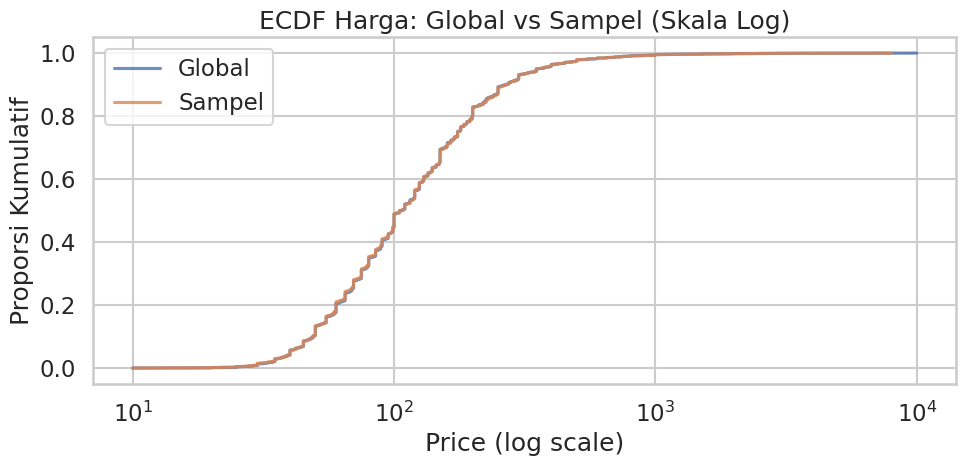

**Interpretasi (bahasa sederhana):**
- Rata-rata selisih harga pada titik kuantil antara data penuh dan sampel adalah 0.60.
- Garis ECDF yang saling dekat berarti bentuk distribusi harga sampel mirip dengan data penuh.
- Kalau dua garis jauh berbeda, hasil analisis dari sampel perlu dipakai dengan hati-hati.

In [78]:
ask_plot("Apakah distribusi harga pada sampel mendekati distribusi harga global?")

q = [0.1, 0.25, 0.5, 0.75, 0.9]
price_comp = pd.DataFrame(
    {
        "quantile": q,
        "price_global": df["price"].quantile(q).values,
        "price_sampel": sample_df["price"].quantile(q).values,
    }
)
price_comp["abs_gap"] = (price_comp["price_global"] - price_comp["price_sampel"]).abs()
display(price_comp)

plt.figure(figsize=(10, 5))
for dset, label in [(df, "Global"), (sample_df, "Sampel")]:
    x = np.sort(dset["price"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label, alpha=0.8)
plt.xscale("log")
plt.title("ECDF Harga: Global vs Sampel (Skala Log)")
plt.xlabel("Price (log scale)")
plt.ylabel("Proporsi Kumulatif")
plt.legend()
plt.tight_layout()
plt.show()

mean_abs_gap_quantile = price_comp["abs_gap"].mean()
explain_plot(
    [
        f"Rata-rata selisih harga pada titik kuantil antara data penuh dan sampel adalah {fmt_num(mean_abs_gap_quantile)}.",
        "Garis ECDF yang saling dekat berarti bentuk distribusi harga sampel mirip dengan data penuh.",
        "Kalau dua garis jauh berbeda, hasil analisis dari sampel perlu dipakai dengan hati-hati.",
    ]
)

## 3) Distribusi Indikator Utama

**Pertanyaan grafik:** Bagaimana bentuk distribusi harga, dan apakah pasar didominasi listing harga rendah-menengah?

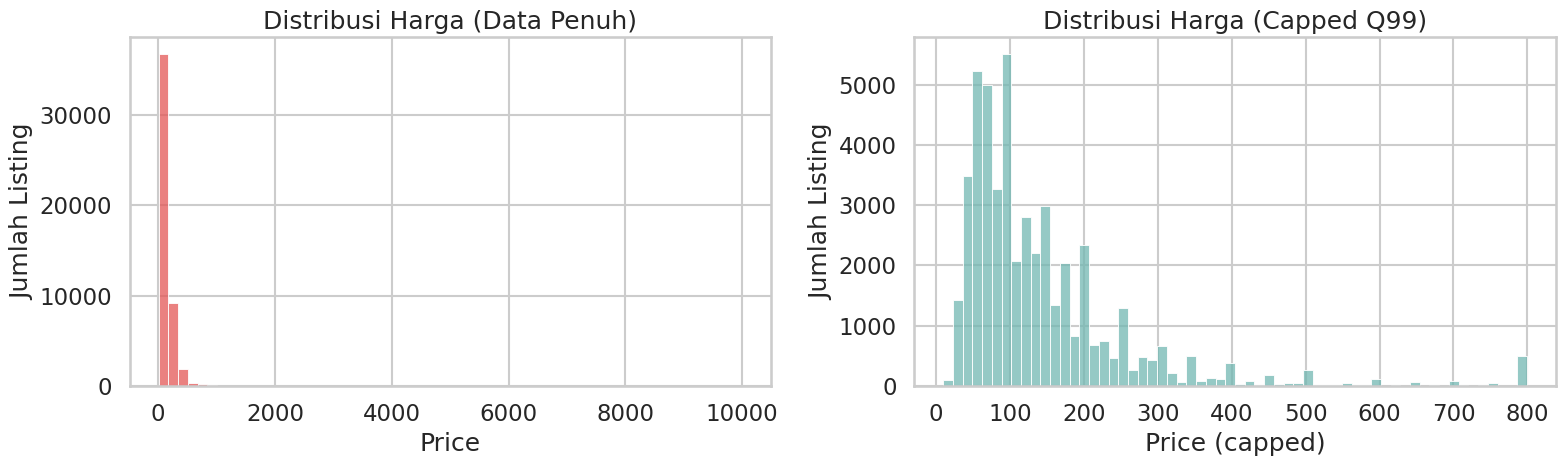

**Interpretasi (bahasa sederhana):**
- Nilai tengah (median) harga adalah 106.00, rata-rata harga 152.76, dan Q90 269.00.
- Saat rata-rata jauh lebih tinggi dari median, artinya ada sedikit listing sangat mahal yang menarik rata-rata naik.
- Untuk keputusan harga, median dan kuantil biasanya lebih aman dipakai daripada hanya rata-rata.

In [79]:
section("3) Distribusi Indikator Utama")

# Versi data untuk visual yang sensitif outlier
price_hi = df["price"].quantile(0.99)
min_nights_hi = df["minimum_nights"].quantile(0.99)

df_vis = df.copy()
df_vis["price_capped"] = df_vis["price"].clip(upper=price_hi)
df_vis["minimum_nights_capped"] = df_vis["minimum_nights"].clip(upper=min_nights_hi)

ask_plot("Bagaimana bentuk distribusi harga, dan apakah pasar didominasi listing harga rendah-menengah?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["price"], bins=60, ax=ax[0], color="#E45756")
ax[0].set_title("Distribusi Harga (Data Penuh)")
ax[0].set_xlabel("Price")
ax[0].set_ylabel("Jumlah Listing")

sns.histplot(df_vis["price_capped"], bins=60, ax=ax[1], color="#72B7B2")
ax[1].set_title("Distribusi Harga (Capped Q99)")
ax[1].set_xlabel("Price (capped)")
ax[1].set_ylabel("Jumlah Listing")

plt.tight_layout()
plt.show()

median_price = df["price"].median()
mean_price = df["price"].mean()
q90_price = df["price"].quantile(0.90)

explain_plot(
    [
        f"Nilai tengah (median) harga adalah {fmt_num(median_price)}, rata-rata harga {fmt_num(mean_price)}, dan Q90 {fmt_num(q90_price)}.",
        "Saat rata-rata jauh lebih tinggi dari median, artinya ada sedikit listing sangat mahal yang menarik rata-rata naik.",
        "Untuk keputusan harga, median dan kuantil biasanya lebih aman dipakai daripada hanya rata-rata.",
    ]
)

**Pertanyaan grafik:** Apakah minimum_nights didominasi sewa jangka pendek, atau banyak listing mensyaratkan sewa panjang?

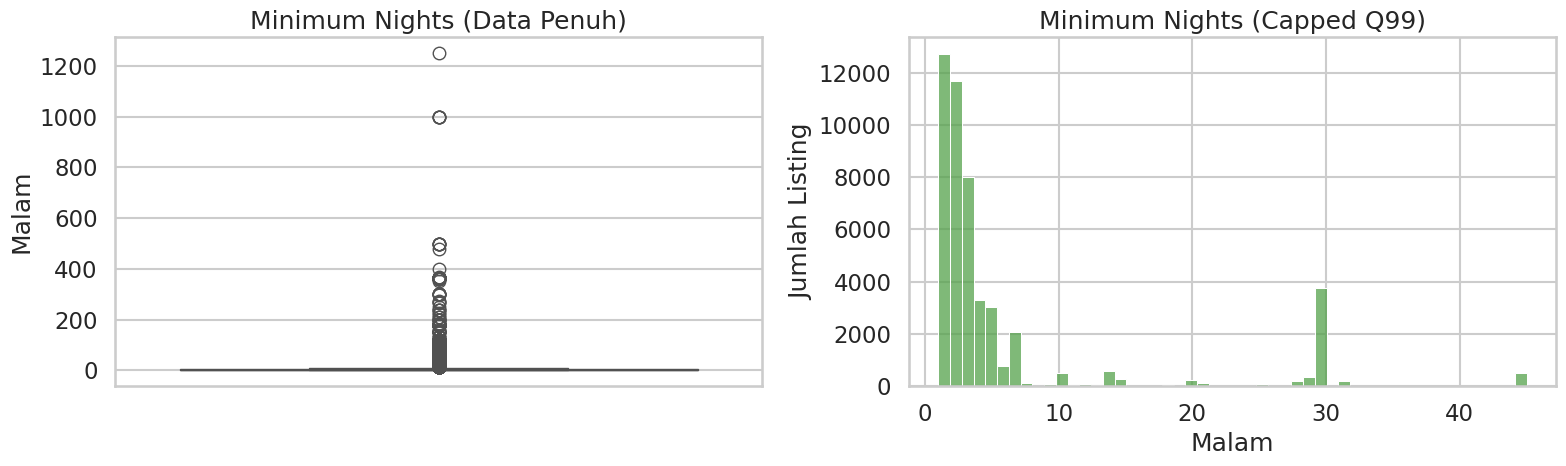

**Interpretasi (bahasa sederhana):**
- Nilai tengah minimum_nights adalah 3.00 malam, sedangkan Q90 adalah 28.00 malam.
- Ini menunjukkan sebagian besar listing meminta sewa singkat, tetapi ada juga sebagian kecil yang meminta sewa jauh lebih lama.
- Karena itu, strategi host lebih tepat jika dibedakan untuk pasar short-stay dan long-stay.

In [80]:
ask_plot("Apakah minimum_nights didominasi sewa jangka pendek, atau banyak listing mensyaratkan sewa panjang?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(y=df["minimum_nights"], ax=ax[0], color="#F58518")
ax[0].set_title("Minimum Nights (Data Penuh)")
ax[0].set_ylabel("Malam")

sns.histplot(df_vis["minimum_nights_capped"], bins=50, ax=ax[1], color="#54A24B")
ax[1].set_title("Minimum Nights (Capped Q99)")
ax[1].set_xlabel("Malam")
ax[1].set_ylabel("Jumlah Listing")

plt.tight_layout()
plt.show()

median_min_nights = df["minimum_nights"].median()
q90_min_nights = df["minimum_nights"].quantile(0.90)

explain_plot(
    [
        f"Nilai tengah minimum_nights adalah {fmt_num(median_min_nights)} malam, sedangkan Q90 adalah {fmt_num(q90_min_nights)} malam.",
        "Ini menunjukkan sebagian besar listing meminta sewa singkat, tetapi ada juga sebagian kecil yang meminta sewa jauh lebih lama.",
        "Karena itu, strategi host lebih tepat jika dibedakan untuk pasar short-stay dan long-stay.",
    ]
)

**Pertanyaan grafik:** Bagaimana pola demand proxy (reviews_per_month) dan ketersediaan listing (availability_365)?

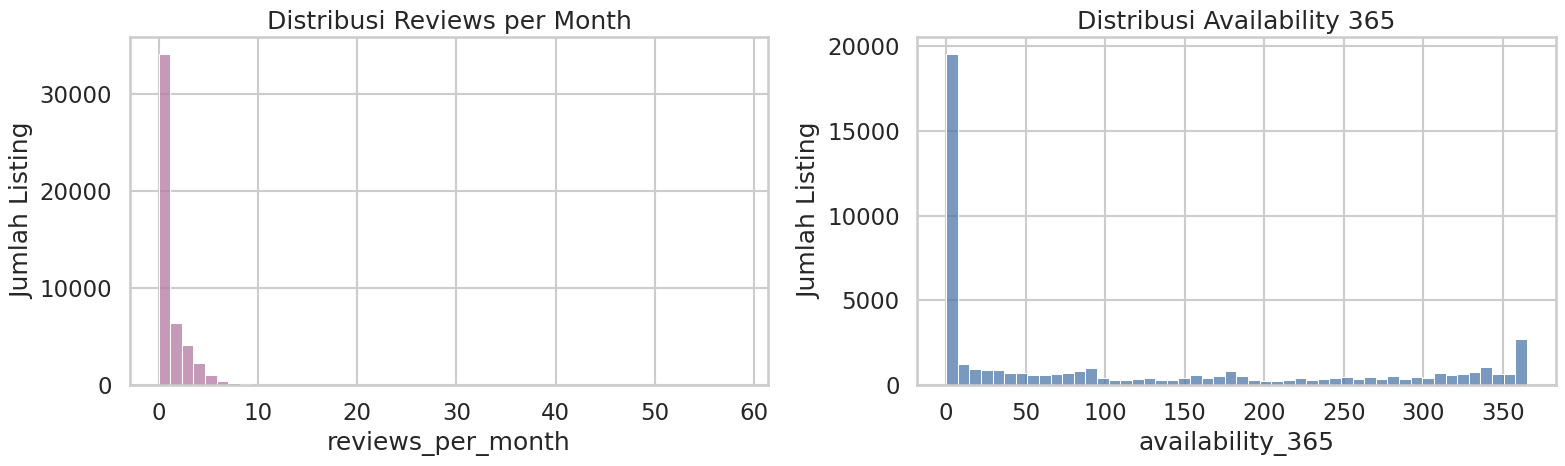

**Interpretasi (bahasa sederhana):**
- Nilai tengah reviews_per_month adalah 0.37, dan nilai tengah availability_365 adalah 45.00 hari.
- reviews_per_month memberi gambaran seberapa sering listing mendapat ulasan, sedangkan availability menunjukkan seberapa sering listing tersedia.
- Dengan melihat keduanya bersama, kita bisa membaca gambaran permintaan dan potensi okupansi secara lebih utuh.

In [81]:
ask_plot("Bagaimana pola demand proxy (reviews_per_month) dan ketersediaan listing (availability_365)?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["reviews_per_month"].fillna(0), bins=50, ax=ax[0], color="#B279A2")
ax[0].set_title("Distribusi Reviews per Month")
ax[0].set_xlabel("reviews_per_month")
ax[0].set_ylabel("Jumlah Listing")

sns.histplot(df["availability_365"], bins=50, ax=ax[1], color="#4C78A8")
ax[1].set_title("Distribusi Availability 365")
ax[1].set_xlabel("availability_365")
ax[1].set_ylabel("Jumlah Listing")

plt.tight_layout()
plt.show()

median_rpm = df["reviews_per_month"].fillna(0).median()
median_avail = df["availability_365"].median()

explain_plot(
    [
        f"Nilai tengah reviews_per_month adalah {fmt_num(median_rpm)}, dan nilai tengah availability_365 adalah {fmt_num(median_avail)} hari.",
        "reviews_per_month memberi gambaran seberapa sering listing mendapat ulasan, sedangkan availability menunjukkan seberapa sering listing tersedia.",
        "Dengan melihat keduanya bersama, kita bisa membaca gambaran permintaan dan potensi okupansi secara lebih utuh.",
    ]
)

## 4) Segmentasi Pasar: Borough dan Room Type

**Pertanyaan grafik:** Bagaimana perbedaan harga antar borough dan antar tipe kamar?

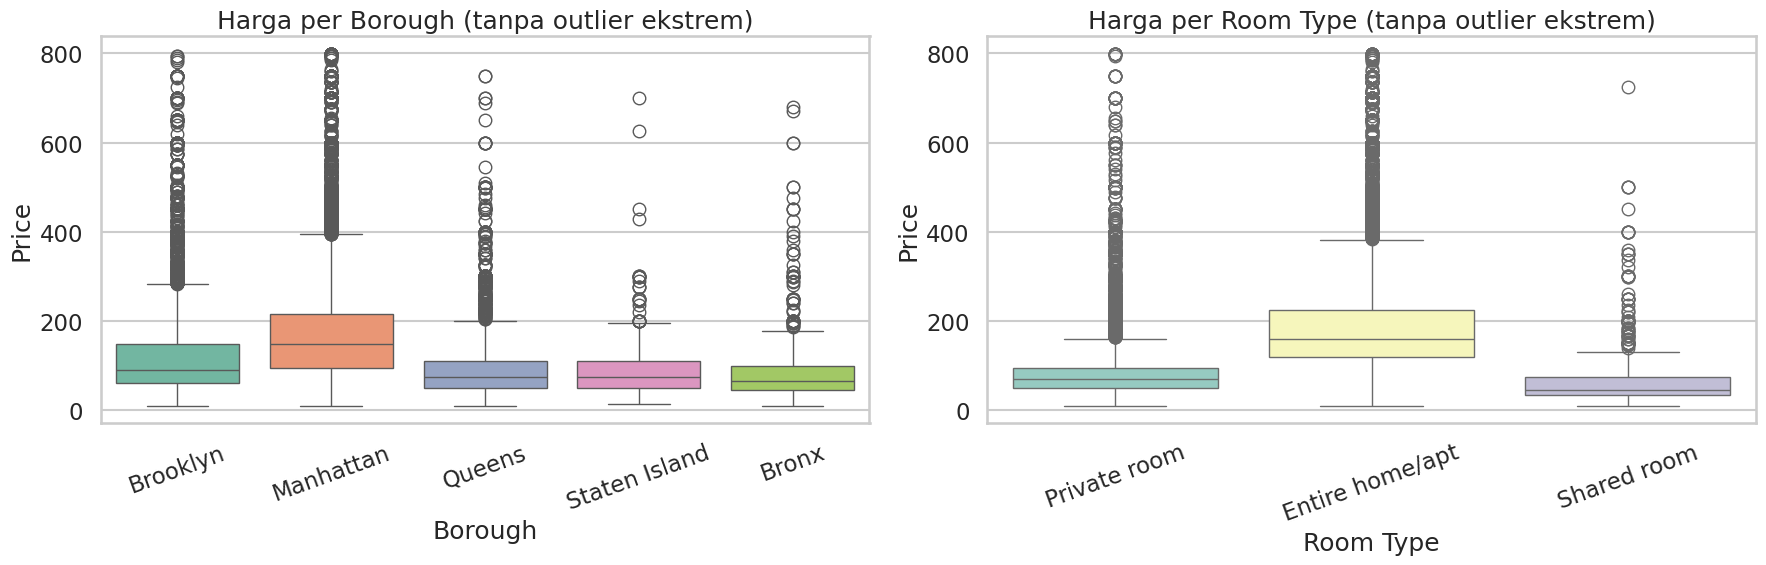

,neighbourhood_group,room_type,median_price
6,Manhattan,Entire home/apt,191.0
3,Brooklyn,Entire home/apt,145.0
9,Queens,Entire home/apt,120.0
12,Staten Island,Entire home/apt,100.0
0,Bronx,Entire home/apt,100.0
7,Manhattan,Private room,90.0
8,Manhattan,Shared room,69.0
4,Brooklyn,Private room,65.0
10,Queens,Private room,60.0
1,Bronx,Private room,54.0


**Interpretasi (bahasa sederhana):**
- Segmen dengan median harga paling tinggi adalah Manhattan - Entire home/apt (191.00).
- Segmen dengan median harga paling rendah adalah Staten Island - Shared room (30.00).
- Perbedaan ini menunjukkan setiap segmen punya karakter harga yang berbeda, jadi satu aturan harga untuk semua segmen biasanya kurang pas.

In [82]:
section("4) Segmentasi Pasar: Borough dan Room Type")

ask_plot("Bagaimana perbedaan harga antar borough dan antar tipe kamar?")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(
    data=df_vis[df_vis["price"] <= price_hi],
    x="neighbourhood_group",
    y="price",
    ax=ax[0],
    palette="Set2",
)
ax[0].set_title("Harga per Borough (tanpa outlier ekstrem)")
ax[0].set_xlabel("Borough")
ax[0].set_ylabel("Price")
ax[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=df_vis[df_vis["price"] <= price_hi],
    x="room_type",
    y="price",
    ax=ax[1],
    palette="Set3",
)
ax[1].set_title("Harga per Room Type (tanpa outlier ekstrem)")
ax[1].set_xlabel("Room Type")
ax[1].set_ylabel("Price")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

price_segment = (
    df.groupby(["neighbourhood_group", "room_type"])["price"]
    .median()
    .rename("median_price")
    .reset_index()
    .sort_values("median_price", ascending=False)
)
display(price_segment.head(10))

highest_segment = price_segment.iloc[0]
lowest_segment = price_segment.iloc[-1]

explain_plot(
    [
        (
            "Segmen dengan median harga paling tinggi adalah "
            f"{highest_segment['neighbourhood_group']} - {highest_segment['room_type']} "
            f"({fmt_num(highest_segment['median_price'])})."
        ),
        (
            "Segmen dengan median harga paling rendah adalah "
            f"{lowest_segment['neighbourhood_group']} - {lowest_segment['room_type']} "
            f"({fmt_num(lowest_segment['median_price'])})."
        ),
        "Perbedaan ini menunjukkan setiap segmen punya karakter harga yang berbeda, jadi satu aturan harga untuk semua segmen biasanya kurang pas.",
    ]
)

**Pertanyaan grafik:** Neighborhood mana yang paling padat listing, dan bagaimana profil harganya?

,listing_count,median_price
neighbourhood,,
Astoria,900,85.0
Lower East Side,911,139.0
Chelsea,1113,199.0
Greenpoint,1114,119.0
East Harlem,1117,99.0
Midtown,1545,210.0
Crown Heights,1564,85.0
Upper East Side,1798,149.0
East Village,1853,150.0


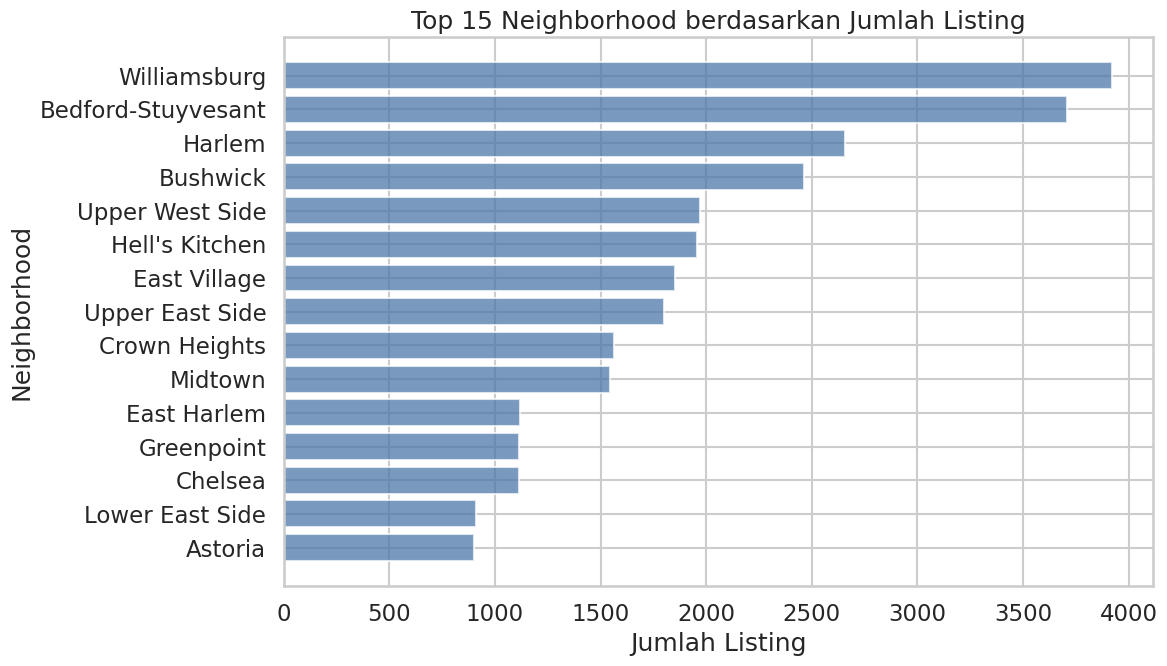

**Interpretasi (bahasa sederhana):**
- Neighborhood dengan jumlah listing terbanyak bisa dianggap sebagai pusat pasokan pasar.
- Dengan membandingkan jumlah listing dan median harga, kita bisa melihat area ramai tetapi murah, atau area yang lebih premium.
- Temuan ini membantu menentukan area mana yang lebih cocok untuk strategi ekspansi host.

In [83]:
ask_plot("Neighborhood mana yang paling padat listing, dan bagaimana profil harganya?")

top_n = 15
top_neigh_count = df["neighbourhood"].value_counts().head(top_n)

top_neigh_price = (
    df[df["neighbourhood"].isin(top_neigh_count.index)]
    .groupby("neighbourhood")["price"]
    .median()
)

neigh_tbl = pd.DataFrame(
    {
        "listing_count": top_neigh_count,
        "median_price": top_neigh_price,
    }
).sort_values("listing_count", ascending=True)

display(neigh_tbl)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.barh(neigh_tbl.index, neigh_tbl["listing_count"], color="#4C78A8", alpha=0.75)
ax1.set_xlabel("Jumlah Listing")
ax1.set_ylabel("Neighborhood")
ax1.set_title("Top 15 Neighborhood berdasarkan Jumlah Listing")
plt.tight_layout()
plt.show()

explain_plot(
    [
        "Neighborhood dengan jumlah listing terbanyak bisa dianggap sebagai pusat pasokan pasar.",
        "Dengan membandingkan jumlah listing dan median harga, kita bisa melihat area ramai tetapi murah, atau area yang lebih premium.",
        "Temuan ini membantu menentukan area mana yang lebih cocok untuk strategi ekspansi host.",
    ]
)

## 5) Perilaku Host dan Ketersediaan Listing

**Pertanyaan grafik:** Seberapa terkonsentrasi pasar pada host dengan banyak listing?

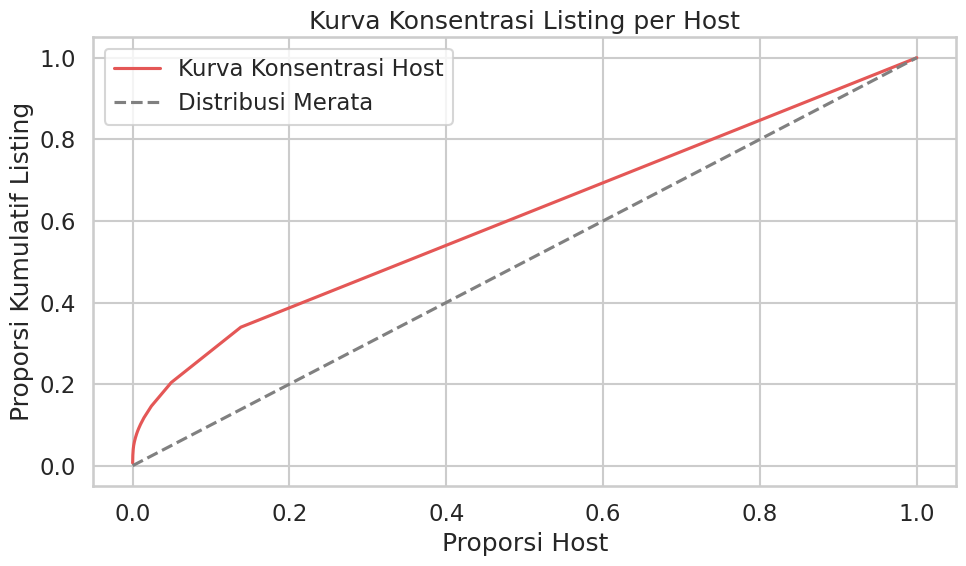

**Interpretasi (bahasa sederhana):**
- Sekitar 10.10% listing dikuasai oleh 1% host teratas.
- Semakin jauh kurva dari garis diagonal, artinya pasar semakin terkonsentrasi pada sedikit host besar.
- Ini berarti keputusan beberapa host besar bisa cukup memengaruhi kondisi pasar.

In [84]:
section("5) Perilaku Host dan Ketersediaan Listing")

ask_plot("Seberapa terkonsentrasi pasar pada host dengan banyak listing?")
host_counts = df.groupby("host_id").size().rename("listing_count").sort_values(ascending=False)

host_share = host_counts / host_counts.sum()
cum_host = np.arange(1, len(host_share) + 1) / len(host_share)
cum_listing = host_share.cumsum().values

plt.figure(figsize=(10, 6))
plt.plot(cum_host, cum_listing, label="Kurva Konsentrasi Host", color="#E45756")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Distribusi Merata")
plt.title("Kurva Konsentrasi Listing per Host")
plt.xlabel("Proporsi Host")
plt.ylabel("Proporsi Kumulatif Listing")
plt.legend()
plt.tight_layout()
plt.show()

top_1pct = max(1, int(len(host_counts) * 0.01))
share_top_1pct = host_counts.head(top_1pct).sum() / host_counts.sum() * 100

explain_plot(
    [
        f"Sekitar {fmt_num(share_top_1pct)}% listing dikuasai oleh 1% host teratas.",
        "Semakin jauh kurva dari garis diagonal, artinya pasar semakin terkonsentrasi pada sedikit host besar.",
        "Ini berarti keputusan beberapa host besar bisa cukup memengaruhi kondisi pasar.",
    ]
)

**Pertanyaan grafik:** Apakah ketersediaan listing berkaitan dengan demand proxy (reviews_per_month)?

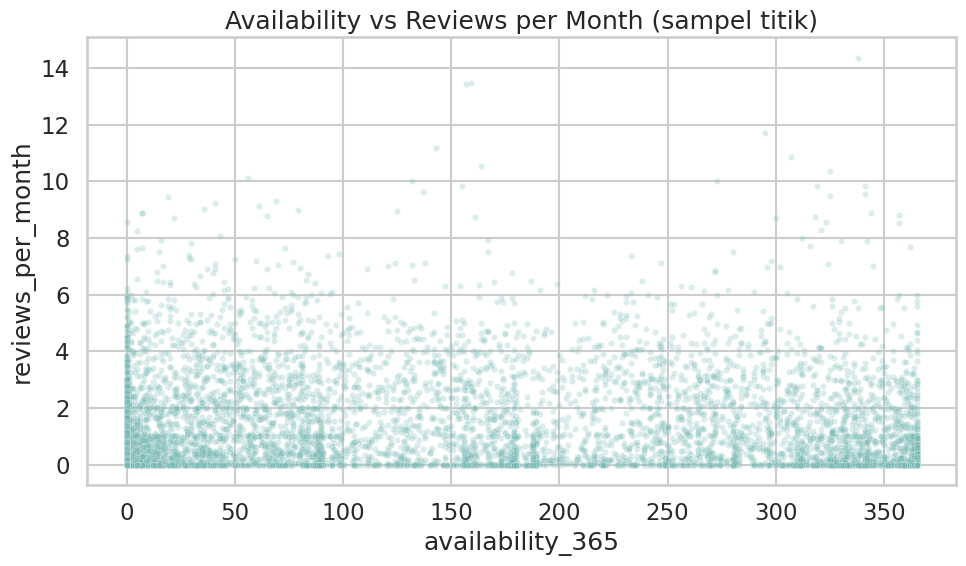

**Interpretasi (bahasa sederhana):**
- Nilai korelasi Pearson antara availability_365 dan reviews_per_month adalah 0.16.
- Nilai korelasi positif berarti pada data ini, listing yang lebih sering tersedia cenderung punya reviews_per_month sedikit lebih tinggi.
- Hubungan ini hanya menunjukkan pola bersama, belum membuktikan sebab-akibat.

In [85]:
ask_plot("Apakah ketersediaan listing berkaitan dengan demand proxy (reviews_per_month)?")
scatter_df = df[["availability_365", "reviews_per_month"]].copy()
scatter_df["reviews_per_month"] = scatter_df["reviews_per_month"].fillna(0)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_df.sample(min(10000, len(scatter_df)), random_state=42),
    x="availability_365",
    y="reviews_per_month",
    alpha=0.25,
    s=20,
    color="#72B7B2",
)
plt.title("Availability vs Reviews per Month (sampel titik)")
plt.xlabel("availability_365")
plt.ylabel("reviews_per_month")
plt.tight_layout()
plt.show()

corr_avail_rpm = scatter_df["availability_365"].corr(scatter_df["reviews_per_month"])
if corr_avail_rpm > 0:
    hubungan_teks = "Nilai korelasi positif berarti pada data ini, listing yang lebih sering tersedia cenderung punya reviews_per_month sedikit lebih tinggi."
elif corr_avail_rpm < 0:
    hubungan_teks = "Nilai korelasi negatif berarti listing yang review-nya lebih sering muncul cenderung tidak terlalu sering tersedia (indikasi okupansi lebih tinggi)."
else:
    hubungan_teks = "Nilai korelasi mendekati nol berarti tidak terlihat hubungan linear yang jelas antara availability dan reviews_per_month."

explain_plot(
    [
        f"Nilai korelasi Pearson antara availability_365 dan reviews_per_month adalah {fmt_num(corr_avail_rpm)}.",
        hubungan_teks,
        "Hubungan ini hanya menunjukkan pola bersama, belum membuktikan sebab-akibat.",
    ]
)

## 6) Pola Spasial Listing

**Pertanyaan grafik:** Apakah lokasi listing membentuk klaster tertentu, dan bagaimana kaitannya dengan harga?

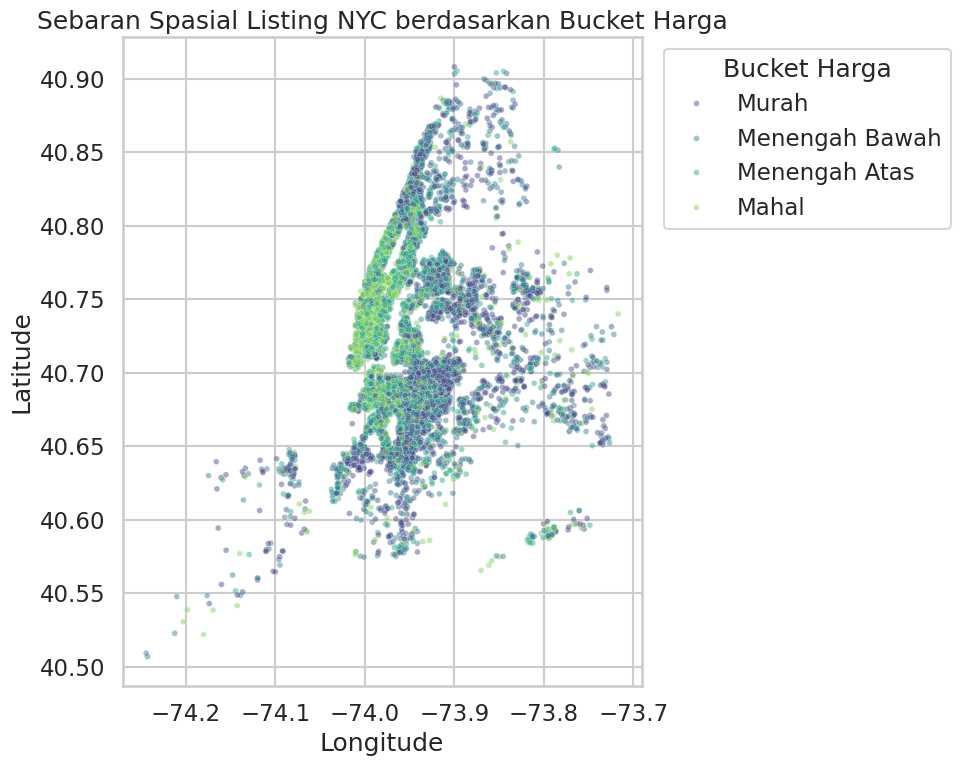

,median_price
neighbourhood_group,
Manhattan,150.0
Brooklyn,90.0
Queens,75.0
Staten Island,75.0
Bronx,65.0


**Interpretasi (bahasa sederhana):**
- Kumpulan titik yang rapat menunjukkan area dengan listing yang terkonsentrasi.
- Perbedaan warna bucket harga antar area menandakan lokasi punya pengaruh kuat terhadap harga.
- Karena itu, rekomendasi harga sebaiknya mempertimbangkan lokasi, bukan hanya fitur listing.

In [86]:
section("6) Pola Spasial Listing")

ask_plot("Apakah lokasi listing membentuk klaster tertentu, dan bagaimana kaitannya dengan harga?")

map_df = df.copy()
map_df["price_bucket"] = pd.qcut(
    map_df["price"].rank(method="first"),
    q=4,
    labels=["Murah", "Menengah Bawah", "Menengah Atas", "Mahal"],
)

plot_map = map_df.sample(min(15000, len(map_df)), random_state=42)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_map,
    x="longitude",
    y="latitude",
    hue="price_bucket",
    alpha=0.45,
    s=18,
    palette="viridis",
)
plt.title("Sebaran Spasial Listing NYC berdasarkan Bucket Harga")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Bucket Harga", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

price_by_borough = df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)
display(price_by_borough.to_frame("median_price"))

explain_plot(
    [
        "Kumpulan titik yang rapat menunjukkan area dengan listing yang terkonsentrasi.",
        "Perbedaan warna bucket harga antar area menandakan lokasi punya pengaruh kuat terhadap harga.",
        "Karena itu, rekomendasi harga sebaiknya mempertimbangkan lokasi, bukan hanya fitur listing.",
    ]
)

In [87]:
section("7) Agregasi Bertahap (Prinsip Skalabilitas)")

# Contoh agregasi bertahap: tahap 1 (detail), tahap 2 (roll-up)
stage_1 = (
    df.groupby(["neighbourhood_group", "room_type"], as_index=False)
    .agg(
        listing_count=("id", "count"),
        median_price=("price", "median"),
        mean_reviews_per_month=("reviews_per_month", "mean"),
    )
)

stage_2 = (
    stage_1.groupby("neighbourhood_group", as_index=False)
    .agg(
        total_listing=("listing_count", "sum"),
        median_of_segment_median_price=("median_price", "median"),
        avg_segment_review_rate=("mean_reviews_per_month", "mean"),
    )
    .sort_values("total_listing", ascending=False)
)

display(Markdown("### Agregasi Tahap 1 (Borough x Room Type)"))
display(stage_1)

display(Markdown("### Agregasi Tahap 2 (Roll-up ke Borough)"))
display(stage_2)

## 7) Agregasi Bertahap (Prinsip Skalabilitas)

### Agregasi Tahap 1 (Borough x Room Type)

,neighbourhood_group,room_type,listing_count,median_price,mean_reviews_per_month
0,Bronx,Entire home/apt,379,100.0,2.238123
1,Bronx,Private room,651,54.0,1.639904
2,Bronx,Shared room,60,40.0,1.351860
3,Brooklyn,Entire home/apt,9558,145.0,1.317773
4,Brooklyn,Private room,10126,65.0,1.254912
5,Brooklyn,Shared room,411,36.0,1.077118
6,Manhattan,Entire home/apt,13198,191.0,1.141610
7,Manhattan,Private room,7982,90.0,1.448949
8,Manhattan,Shared room,480,69.0,1.792781
9,Queens,Entire home/apt,2096,120.0,1.967302


### Agregasi Tahap 2 (Roll-up ke Borough)

,neighbourhood_group,total_listing,median_of_segment_median_price,avg_segment_review_rate
2,Manhattan,21660,90.0,1.461113
1,Brooklyn,20095,65.0,1.216601
3,Queens,5666,60.0,1.812719
0,Bronx,1090,54.0,1.743296
4,Staten Island,373,50.0,1.701861


In [88]:
section("8) Batasan Analisis dan Rekomendasi Realistis")

limitations = [
    "Data ini adalah snapshot tahun 2019, jadi belum menggambarkan perubahan pasar setelah tahun itu.",
    "reviews_per_month dipakai sebagai perkiraan permintaan, bukan ukuran okupansi yang benar-benar pasti.",
    "Analisis ini bersifat deskriptif; hubungan antar variabel belum bisa dianggap sebagai sebab-akibat.",
    "Bias sampling masih bisa muncul jika analisis lanjutan memakai sebagian data tanpa cek keterwakilan.",
]

recommendations = [
    "Untuk strategi harga, utamakan median dan kuantil, jangan hanya rata-rata, agar hasil lebih tahan terhadap outlier.",
    "Pisahkan strategi per borough dan room_type karena pola harganya memang berbeda.",
    "Pantau host dengan listing sangat banyak karena mereka bisa cukup memengaruhi pasar lokal.",
    "Saat data makin besar dan diperbarui, tetap gunakan pola projection-filter-agregasi bertahap agar proses tetap efisien.",
]

display(Markdown("### Batasan Analisis"))
for i, lim in enumerate(limitations, start=1):
    display(Markdown(f"{i}. {lim}"))

display(Markdown("### Rekomendasi Realistis"))
for i, rec in enumerate(recommendations, start=1):
    display(Markdown(f"{i}. {rec}"))

## 8) Batasan Analisis dan Rekomendasi Realistis

### Batasan Analisis

1. Data ini adalah snapshot tahun 2019, jadi belum menggambarkan perubahan pasar setelah tahun itu.

2. reviews_per_month dipakai sebagai perkiraan permintaan, bukan ukuran okupansi yang benar-benar pasti.

3. Analisis ini bersifat deskriptif; hubungan antar variabel belum bisa dianggap sebagai sebab-akibat.

...

### Rekomendasi Realistis

1. Untuk strategi harga, utamakan median dan kuantil, jangan hanya rata-rata, agar hasil lebih tahan terhadap outlier.

2. Pisahkan strategi per borough dan room_type karena pola harganya memang berbeda.

3. Pantau host dengan listing sangat banyak karena mereka bisa cukup memengaruhi pasar lokal.

4. Saat data makin besar dan diperbarui, tetap gunakan pola projection-filter-agregasi bertahap agar proses tetap efisien.